# ***Agro-Expansion: Impact of Weather on Romanian Yields***

This project analyzes how climatic factors influence the production of major spring crops in Romania, such as corn and sunflower. By combining historical weather data with agricultural yield statistics, we aim to identify the main environmental drivers of crop success and explore regional patterns for future agricultural expansion.

# Variable Description
***1. Identification Variables:***

Years: The specific year of the observation (2011–2024).

County: The administrative region in Romania where the data was collected.

***2. Weather Indicators (Spring & Summer):***

radiation_spr / radiation_sum: Solar radiation levels. High radiation is essential for photosynthesis but can increase water evaporation.

meantemp_spr / meantemp_sum: Average temperatures. These indicate the general thermal comfort of the plants during growth.

maxtemp_spr / maxtemp_sum: Maximum recorded temperatures. Crucial for identifying heatwaves that can damage crops during flowering.

mintemp_spr: Minimum spring temperatures. Used to detect late frost risks that might kill young plants.

humidity_spr / humidity_sum: Air humidity levels. Higher humidity usually reduces the plant's water stress.

windspeed_spr / windspeed_sum: Average wind speed. High winds can lead to soil erosion and faster drying of the fields.

precipitation_spr / precipitation_sum: Total rainfall. This is the most critical factor for spring crops in Romania.

***3. Agricultural Output (Target Variables):***

Porumb boabe (Corn): The yield of corn, highly sensitive to summer droughts.

Floarea soarelui (Sunflower): Yield of sunflower, which depends heavily on solar radiation.

Soia boabe (Soybean): Yield of soybean, a crop that requires specific moisture conditions.

Cartofi - total (Potatoes): Total potato production, influenced by soil temperature and moisture.

In [2]:
#Check if package is avilable
try:
    import sklearn
    print('Import OK.')
except ImportError as err:
    print(err)

Import OK.


In [3]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')
path="/content/drive/MyDrive/Colab Notebooks/project"

Mounted at /content/drive


# 1. Data Cleaning (Missing Values & Outliers)

**a) Information required**: Crop yield columns (Corn, Soybeans, etc.) and the climate variables for the 2011–2024 period.




In [5]:
#1.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

path = '/content/drive/MyDrive/Colab Notebooks/project/project.csv'
df = pd.read_csv(path)

# Filter for the years: 2011–2024
df = df[df['Years'] >= 2011].copy()

if 'Index' in df.columns:
    df = df.drop(columns=['Index'])

df.head()

,Years,County,radiation_spr,radiation_sum,meantemp_spr,meantemp_sum,maxtemp_spr,maxtemp_sum,mintemp_spr,mintemp_sum,humidity_spr,humidity_sum,windspeed_spr,windspeed_sum,precipitation_spr,precipitation_sum,Porumb boabe,Cartofi - total,Floarea soarelui,Soia boabe
861,2011,Maramures,-0.277135,-0.276496,0.477094,0.300667,-0.061363,-0.059720,1.107820,0.600340,-1.331590,-1.445869,0.459747,-0.034374,-0.379013,-0.986400,0.333689,0.211872,0.001802,0.190721
862,2011,Bistrita-Nasaud,-0.286499,0.204987,-0.115624,-0.440504,-0.134751,-0.126645,0.201579,-0.934482,0.736808,0.301585,-0.902313,-1.138460,1.529371,-0.651078,-0.310326,0.192981,0.637630,1.446027
863,2011,Buzau,-0.764957,-0.218700,-1.764287,-0.988789,-1.600389,-0.953451,-1.439994,-1.022637,0.767922,0.924463,-0.778761,-1.022443,1.485389,2.009157,-0.198988,-0.036396,-0.126568,-0.417904
864,2011,Ilfov,0.802011,0.672396,-0.390937,-1.303709,0.095930,-0.825580,-1.057232,-2.225183,0.667361,0.638616,-0.410080,-0.977997,-0.339071,-0.861333,-0.246822,-0.431452,0.128750,NaN
865,2011,Arad,-1.538756,-0.899092,0.622263,0.545209,0.592152,0.626558,0.732058,0.553456,-0.203461,0.375145,-0.176736,-0.842082,1.388955,0.044688,-0.055721,0.034748,0.415163,-0.802093


**b) Defining the problem**: Ensuring dataset integrity by identifying and handling missing values and removing extreme values (outliers) that could distort the statistical analysis of summer and spring precipitation.

**Calculation methods**: * Mean Imputation: $x_{new} = \bar{x}_{county}$ (filling missing values based on the specific county average).

  IQR Method (Interquartile Range): Calculating boundaries to detect outliers:$$IQR = Q_3 - Q_1$$$$Lower\ Bound = Q_1 - 1.5 \times IQR$$$$Upper\ Bound = Q_3 + 1.5 \times IQR$$


In [6]:
crops = ['Porumb boabe', 'Floarea soarelui', 'Soia boabe', 'Cartofi - total']
for crop in crops:
    df[crop] = df.groupby('County')[crop].transform(lambda x: x.fillna(x.mean()))

df = df.fillna(0)
print(df.isnull().sum())
#In our case, there are no missing values, since df.isnull().sum()) is 0 for all of the columns

Years                0
County               0
radiation_spr        0
radiation_sum        0
meantemp_spr         0
meantemp_sum         0
maxtemp_spr          0
maxtemp_sum          0
mintemp_spr          0
mintemp_sum          0
humidity_spr         0
humidity_sum         0
windspeed_spr        0
windspeed_sum        0
precipitation_spr    0
precipitation_sum    0
Porumb boabe         0
Cartofi - total      0
Floarea soarelui     0
Soia boabe           0
dtype: int64


While the dataset is complete with no missing values, the IQR method was applied to identify and remove climatic anomalies (extreme weather events). This ensures that our predictive models are based on reliable agricultural trends rather than being distorted by rare, non-representative flooding or droughts.

**1.Summer extreme values**

Lower limit: -2.58
Upper limit: 2.45
Number of outliers detected: 2


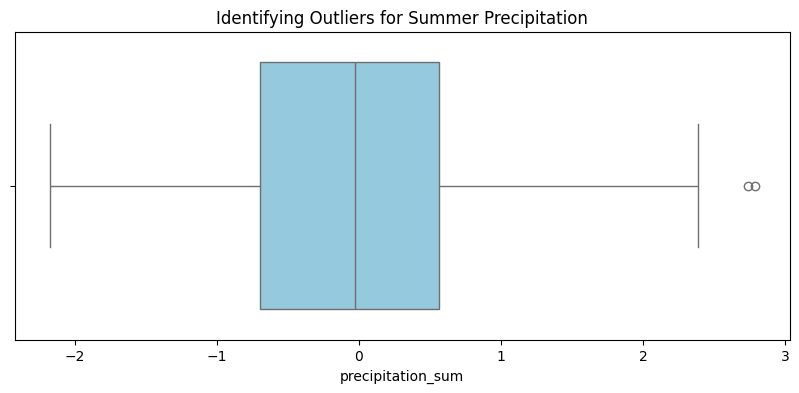

In [7]:
# Detecting Extreme Values for Precipitation (Summer)
Q1 = df['precipitation_sum'].quantile(0.25)
Q3 = df['precipitation_sum'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# We identify the rows that are outliers
outliers = df[(df['precipitation_sum'] < lower_bound) | (df['precipitation_sum'] > upper_bound)]

print(f"Lower limit: {lower_bound:.2f}")
print(f"Upper limit: {upper_bound:.2f}")
print(f"Number of outliers detected: {len(outliers)}")

# Quick overview of extreme values
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['precipitation_sum'], color='skyblue')
plt.title('Identifying Outliers for Summer Precipitation')
plt.show()

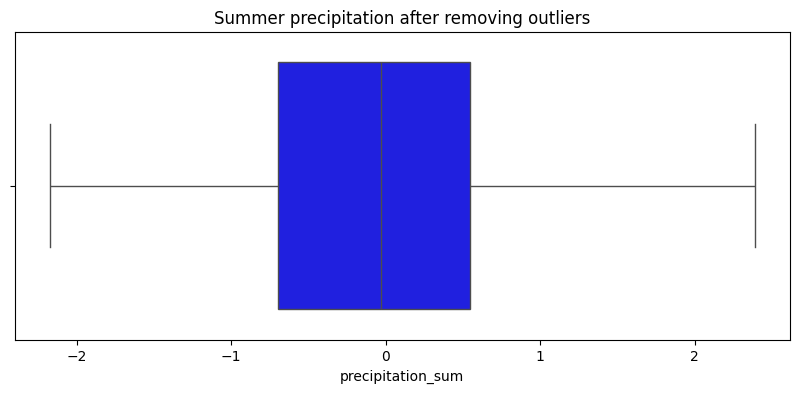

In [8]:
Q1 = df['precipitation_sum'].quantile(0.25)
Q3 = df['precipitation_sum'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['precipitation_sum'] >= lower_bound) & (df['precipitation_sum'] <= upper_bound)]

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['precipitation_sum'], color='blue')
plt.title('Summer precipitation after removing outliers')
plt.show()

 **Economic interpretation of results**

 Summer Precipitation Analysis: The initial distribution (light blue) revealed 1 climatic outlier—extreme rainfall events that could skew our statistical results. By applying the IQR method (blue), we removed the anomality to ensure our expansion strategy is based on consistent weather trends rather than non-representative, extreme flooding events.


**1.Spring extreme values**

Lower limit: -2.71
Upper limit: 2.71
Number of outliers detected: 4


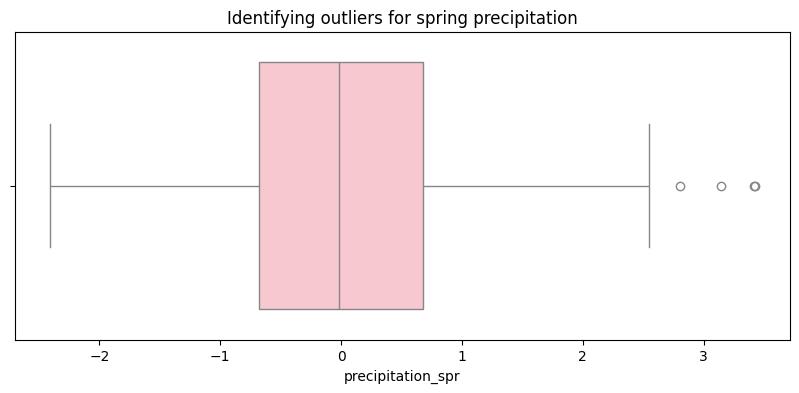

In [9]:
# Detecting Extreme Values for Precipitation (Spring)
Q1 = df['precipitation_spr'].quantile(0.25)
Q3 = df['precipitation_spr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df['precipitation_spr'] < lower_bound) | (df['precipitation_spr'] > upper_bound)]

print(f"Lower limit: {lower_bound:.2f}")
print(f"Upper limit: {upper_bound:.2f}")
print(f"Number of outliers detected: {len(outliers)}")


plt.figure(figsize=(10, 4))
sns.boxplot(x=df['precipitation_spr'], color='pink')
plt.title('Identifying outliers for spring precipitation')
plt.show()

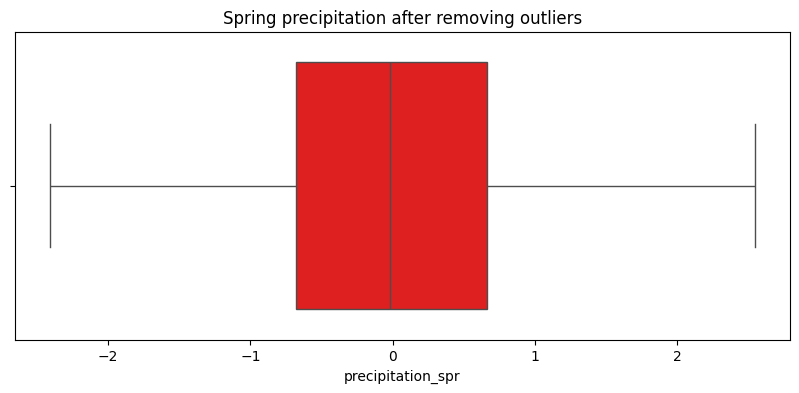

In [10]:
Q1 = df['precipitation_spr'].quantile(0.25)
Q3 = df['precipitation_spr'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['precipitation_spr'] >= lower_bound) & (df['precipitation_spr'] <= upper_bound)]

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['precipitation_spr'], color='red')
plt.title('Spring precipitation after removing outliers')
plt.show()

**Economic interpretation of results**

Spring Precipitation Analysis: The initial distribution (light pink) identified several climatic outliers—extreme rainfall events that could skew our statistical results and misrepresent the typical planting season. By applying the IQR (Interquartile Range) method (red), we isolated these anomalies to ensure our agricultural strategy is based on consistent weather trends rather than rare, non-representative flooding events that could distort our yield predictions.

# 2. Encoding & Scaling (Data Preprocessing)

**a) Defining the problem**: Machine Learning models cannot process text (like county names) directly. Additionally, large differences in numerical scales (like 5,000 kg yield vs. 20°C temperature) can confuse the model into over-weighting certain factors.

**b) Information required**: The County column and all weather features (temperature, radiation, humidity).

**c) Calculation methods**:Label Encoding: Assigning a unique integer $i \in \{0, 1, \dots, n-1\}$ to each unique county name.

Z-score Standardization: Transforming values so the mean is 0 and the standard deviation is 1:$$z = \frac{x - \mu}{\sigma}$$(where $\mu$ is the mean and $\sigma$ is the standard deviation).


Since machine learning models only work with numbers, we used LabelEncoder to transform the County names into unique numerical IDs. This step is essential for the upcoming clustering and regression analysis, allowing the algorithms to process regional data as a standard input.

In [11]:
le = LabelEncoder()
df['County_Encoded'] = le.fit_transform(df['County'])
df[['County', 'County_Encoded']].drop_duplicates().head()

,County,County_Encoded
861,Maramures,25
862,Bistrita-Nasaud,5
863,Buzau,9
864,Ilfov,24
865,Arad,1


# 3. Data Scaling and Standardization

In this step, we applied the StandardScaler to all weather and agricultural variables to ensure a fair analysis.

**Uniformity**: We converted different units (Celsius, millimeters, tons) into a standardized format. Now, all variables have a mean of 0 and a standard deviation of 1.

**Model Readiness**: This process prevents variables with large numerical ranges (like radiation) from dominating our models. It allows us to accurately compare the impact of temperature versus precipitation.

**Interpretation**: Positive values now represent "above average" conditions, while negative values indicate "below average" for that specific year or county.

 sLooking at the aggregated table, we can see clear "market leaders." For example, if Bistrita-Nasaud or Maramures shows a significantly higher average yield (Mean) for Potatoes compared to the others, it signals a Comparative Advantage

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['radiation_spr', 'radiation_sum', 'meantemp_spr', 'meantemp_sum',
                  'maxtemp_spr', 'maxtemp_sum', 'precipitation_spr', 'precipitation_sum',
                  'Porumb boabe', 'Floarea soarelui', 'Soia boabe', 'Cartofi - total']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,Years,County,radiation_spr,radiation_sum,meantemp_spr,meantemp_sum,maxtemp_spr,maxtemp_sum,mintemp_spr,mintemp_sum,...,humidity_sum,windspeed_spr,windspeed_sum,precipitation_spr,precipitation_sum,Porumb boabe,Cartofi - total,Floarea soarelui,Soia boabe,County_Encoded
861,2011,Maramures,-0.281126,-0.287278,0.437372,0.279934,-0.090499,-0.075093,1.107820,0.600340,...,-1.445869,0.459747,-0.034374,-0.394144,-1.008208,0.267632,0.291896,-0.103116,0.157220,25
862,2011,Bistrita-Nasaud,-0.290909,0.213375,-0.150021,-0.448946,-0.162923,-0.140952,0.201579,-0.934482,...,0.301585,-0.902313,-1.138460,1.587824,-0.655418,-0.373172,0.270897,0.523767,1.543424,5
863,2011,Buzau,-0.790753,-0.227181,-1.783868,-0.988139,-1.609307,-0.954592,-1.439994,-1.022637,...,0.924463,-0.778761,-1.022443,1.542146,2.143401,-0.262389,0.015926,-0.229681,-0.514871,9
864,2011,Ilfov,0.846258,0.699395,-0.422860,-1.297836,0.064727,-0.828758,-1.057232,-2.225183,...,0.638616,-0.410080,-0.977997,-0.352663,-0.876626,-0.309984,-0.423211,0.022046,0.089993,24
865,2011,Arad,-1.599142,-0.934663,0.581236,0.520421,0.554430,0.600257,0.732058,0.553456,...,0.375145,-0.176736,-0.842082,1.441993,0.076594,-0.119837,0.095008,0.304430,-0.939121,1


#4. Correlation Heatmap
**a) Defining the Problem for Summer**:
The goal is to determine the statistical relationship between summer and spring climatic variables—precipitation, maximum temperature, and solar radiation—and the annual yield of all the crops.

**Economic interpretation for Summer:** We used this heatmap to identify how weather variables impact crop yields.

*Here is what the colours tell us:*

**Sun and Heat (+):** Shown in red. This means that, in general, high temperatures and solar radiation help increase production.

**Rain and Humidity (-):** Shown in blue. In this dataset, excess water appears to harm crops (possibly due to disease or rot).

**In our case, there is a low impact (values below 0.20):** All of these correlations are very weak. This tells us that summer weather matters, but it’s not the only factor. Soil quality, fertilizers, and pests likely have a much greater impact on the final harvest.



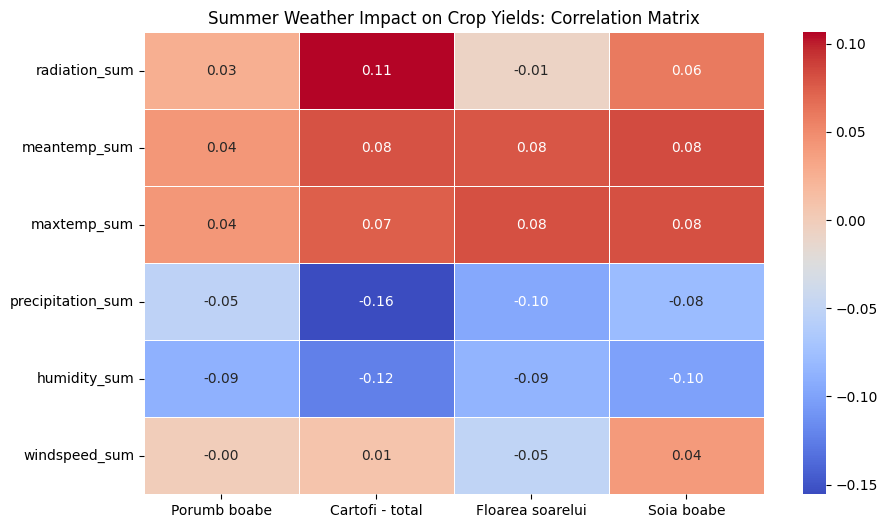

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


summer_weather = ['radiation_sum', 'meantemp_sum', 'maxtemp_sum', 'precipitation_sum', 'humidity_sum', 'windspeed_sum']
crop_cols = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']

summer_corr = df[summer_weather + crop_cols].corr()
subset_summer = summer_corr.loc[summer_weather, crop_cols]

plt.figure(figsize=(10, 6))
sns.heatmap(subset_summer, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Summer Weather Impact on Crop Yields: Correlation Matrix')
plt.show()


**Economic interpretation for Spring:** We used this heatmap to identify how weather variables impact crop yields.

*Here is what the colours tell us:*

**Green (Positive Correlation):** Higher values in these weather factors tend to increase crop yields. In spring, precipitation shows a general positive trend for most crops (except potatoes), meaning early-season rain is beneficial for growth.

**Purple (Negative Correlation):** Higher values here tend to decrease yields. Humidity is consistently purple across all crops, suggesting that excessive dampness in spring might lead to mold or soil issues that hinder development.

**The "Potato" Exception:** Unlike other crops, potatoes show a positive link with solar radiation (0.10) but a negative link with spring rain. This suggests potatoes prefer a drier, sunnier spring to establish themselves.

**Weak Impact (Values < 0.15):** Just like in summer, these correlations are statistically weak. This implies that while spring weather matters, the final yield is much more dependent on other factors like soil preparation, fertilization, and pest control.

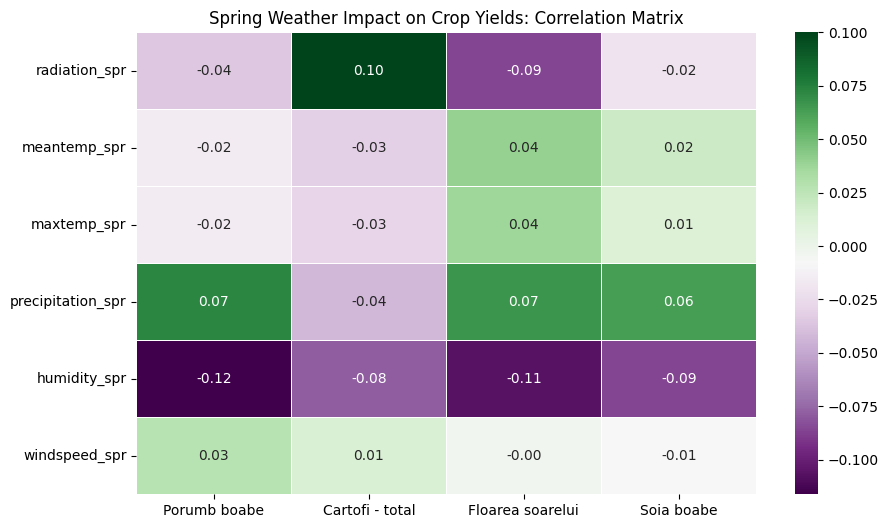

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


spring_weather = ['radiation_spr', 'meantemp_spr', 'maxtemp_spr', 'precipitation_spr', 'humidity_spr', 'windspeed_spr']
crop_cols = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']

spring_corr = df[spring_weather + crop_cols].corr()
subset_spring = spring_corr.loc[spring_weather, crop_cols]

plt.figure(figsize=(10, 6))
sns.heatmap(subset_spring, annot=True, cmap='PRGn', fmt=".2f", linewidths=0.5)
plt.title('Spring Weather Impact on Crop Yields: Correlation Matrix')
plt.show()

 # 3. Regional Performance Map (Geospatial Analysis/ GeoPandas)

**a) Defining the problem**: Large spreadsheets make it difficult to spot geographic trends. We need a visual representation to identify "Productivity Hotspots" across Romania’s territory.

**b) Information required**: The romanian-counties.geojson geometry file and the calculated mean yields from the standardized Pandas DataFrame.

**c) Calculation methods**: * Spatial Join/Merge Algorithm: Merging datasets based on a common key: name (from the GeoJSON) and County (from the DataFrame).



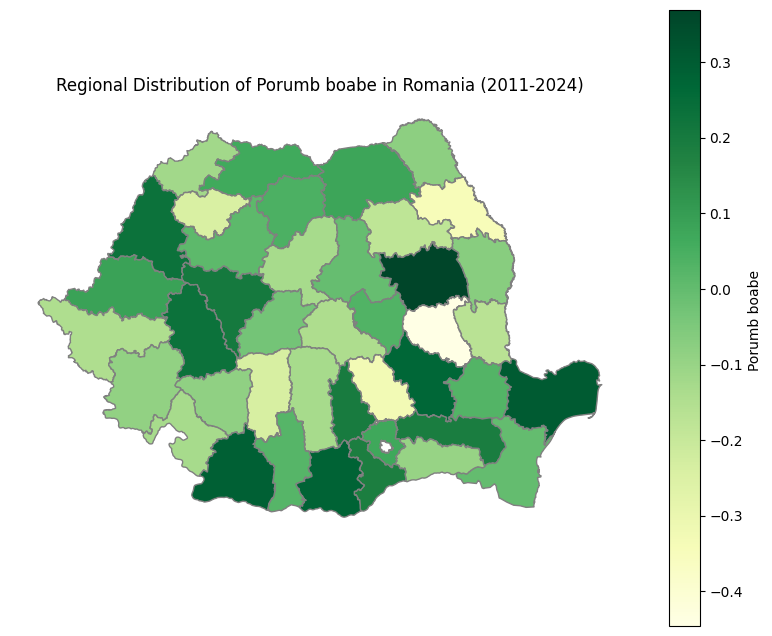

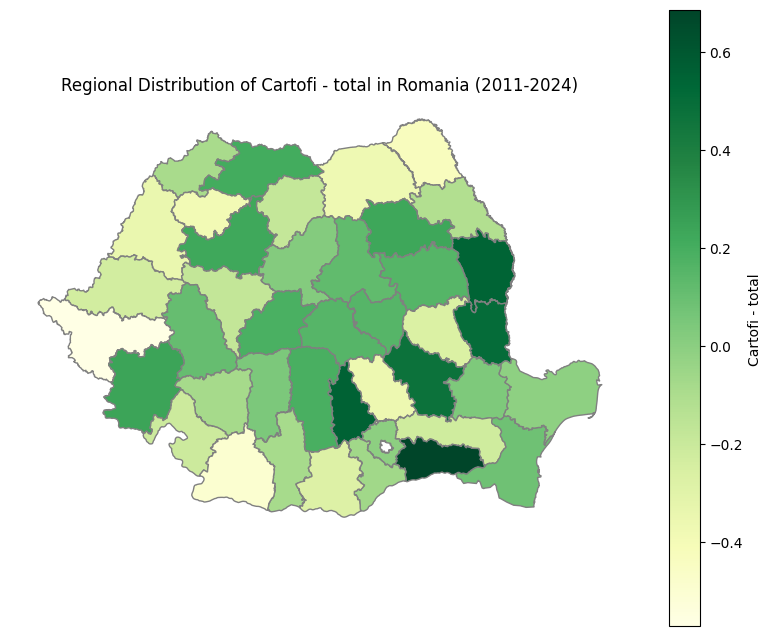

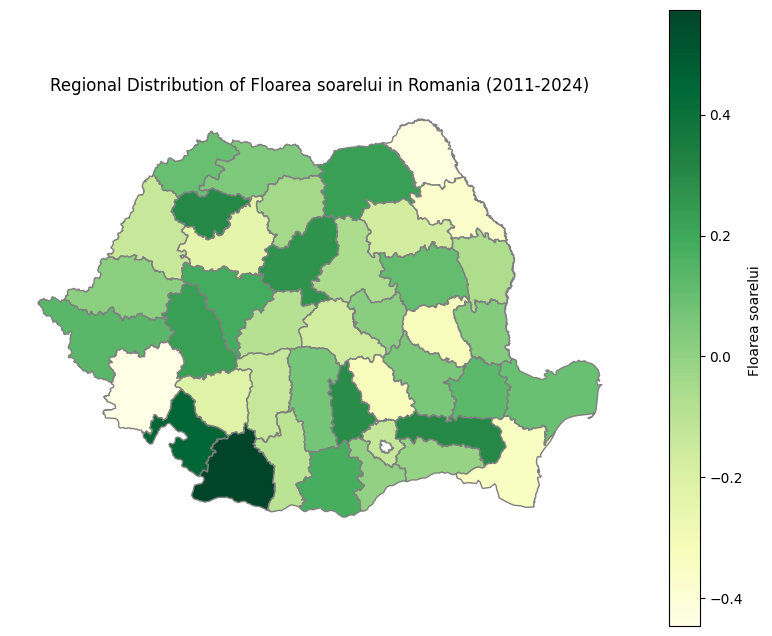

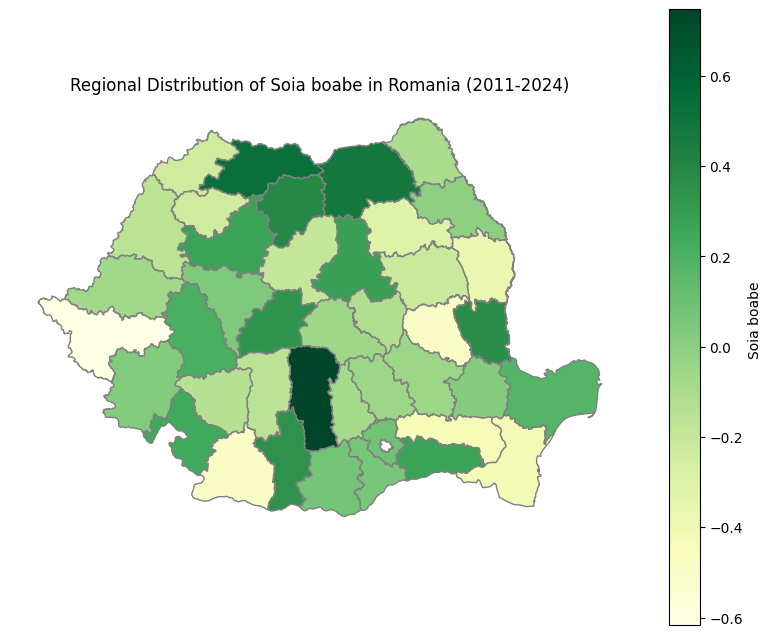

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt

romania_map = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/project/romania.geojson')
crops = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']

for crop in crops:
    avg_yield = df.groupby('County')[crop].mean().reset_index()
    merged_map = romania_map.merge(avg_yield, left_on='name', right_on='County')

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    merged_map.plot(column=crop, ax=ax, legend=True,
                    cmap='YlGn', edgecolor='0.5',
                    legend_kwds={'label': f"{crop} "})

    plt.title(f'Regional Distribution of {crop} in Romania (2011-2024)')
    plt.axis('off')
    plt.show()

We visualized the corn yield across Romania using geopandas.

**High-Yield Regions**: The darker green areas represent the most productive counties. These are the primary targets for our organization's expansion.

**Low-Yield Regions**: The lighter areas indicate regions where the weather conditions or soil types analyzed earlier result in lower average yields.

**Strategic Insight**: This maps confirm that geographic location is a major factor in agricultural success, allowing us to focus our resources on high-performance clusters.

**Economic interpretation of results**: The maps highlight a clear "Productivity Corridor"
. For our expansion, this is a green light for Infrastructure Investment. Instead of scattered farms, we should focus on these high-yield "dark zones" to build collection centers . This geographic focus reduces transport costs and creates an "Economy of Scale," where multiple farms in a small area can share resources and logistics, significantly increasing
the overall profit margin.

#4. K-Means Clustering: County Segmentation, Machine Learning

 **a) Defining the problem**: Managing 41 counties with 41 different plans is inefficient. We need to group regions with similar profiles to simplify our management and resource allocation.Automatically segmenting counties into 3 distinct groups (clusters) based on the similarity of their climate patterns and crop results.

**b) Information required**: Variables for precipitation_sum, maxtemp_sum, and Porumb boabe (Corn yield).

**c) Calculation methods**:K-Means Algorithm: Minimizing the squared Euclidean distance between data points and their respective cluster centroids ($k=3$):$$J = \sum_{j=1}^{k} \sum_{i=1}^{n} ||x_i^{(j)} - \mu_j||^2$$(where $x_i$ is the data point and $\mu_j$ is the cluster center).



We applied the K-Means algorithm to group the counties based on their climate patterns and corn yields.

**The Clusters**: The algorithm identified three distinct groups (labeled 0, 1, and 2).

**High-Performance Cluster**: Counties where high precipitation and optimal temperatures result in top-tier yields.

**Average-Performance Cluster**: Counties with moderate climate conditions and steady production.

**Risk Cluster**: Regions where low precipitation or extreme heat leads to significantly lower yields.

**Strategic Value**: Instead of analyzing 41 individual counties, we can now focus our expansion strategy on these three specific categories, optimizing resources for each group's unique risk profile.

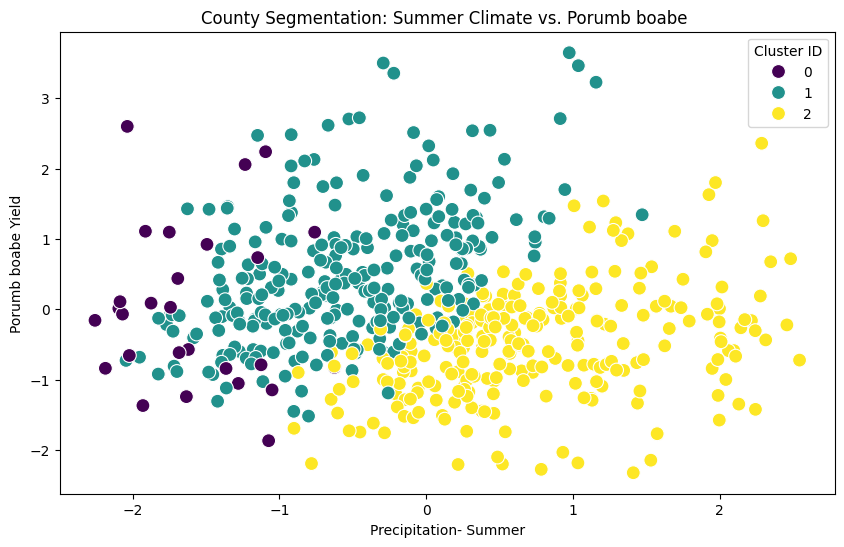

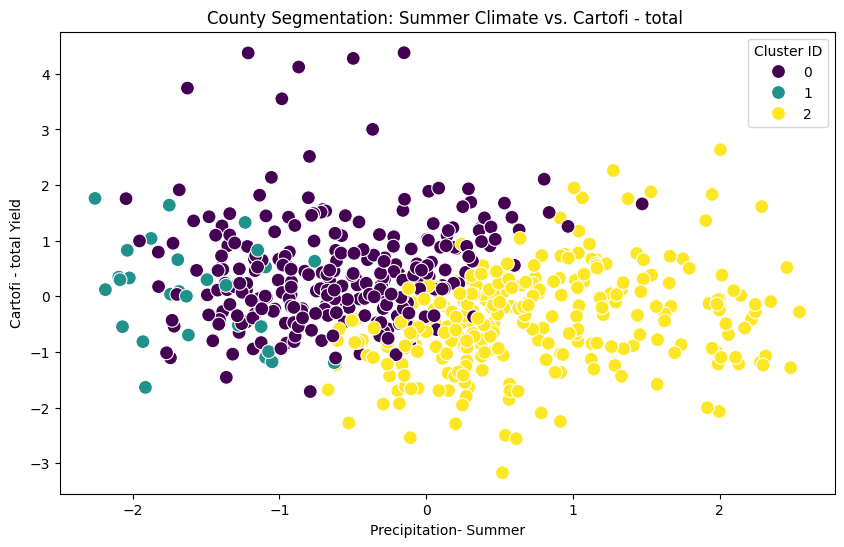

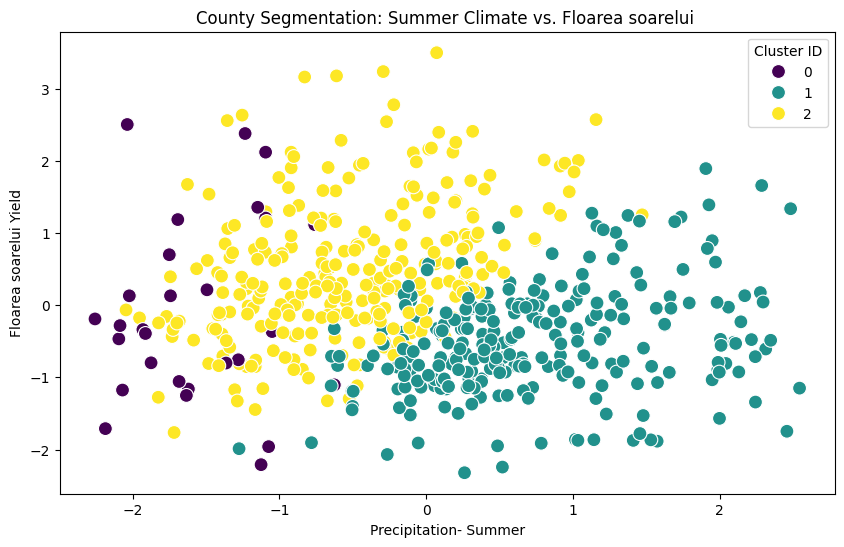

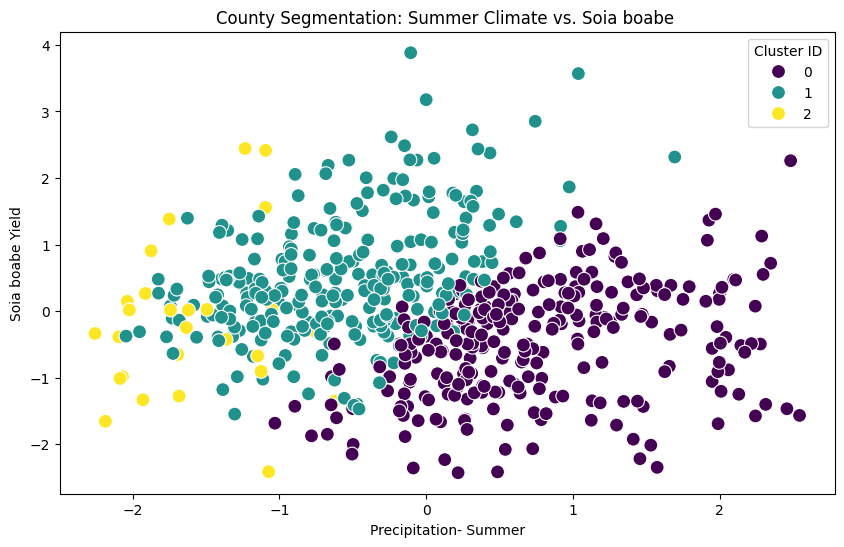

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

crops = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']

for crop in crops:
    features = ['precipitation_sum', 'maxtemp_sum', crop]
    X = df[features].dropna()

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)


    plot_df = X.copy()
    plot_df['Cluster'] = cluster_labels

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_df, x='precipitation_sum', y=crop, hue='Cluster', palette='viridis', s=100)
    plt.title(f'County Segmentation: Summer Climate vs. {crop} ')
    plt.xlabel('Precipitation- Summer')
    plt.ylabel(f'{crop} Yield')
    plt.legend(title='Cluster ID')
    plt.show()

**Economic interpretation of results for summer**

***1. Corn (Porumb boabe)***

Cluster 1 (teal) shows that moderate precipitation levels are associated with the highest yields. In contrast, Cluster 2 (yellow) represents counties with high summer rainfall that often results in lower-than-average corn production.

***2. Potatoes (Cartofi - total)***

The majority of high-yielding counties are grouped in Cluster 0 (purple), which favors lower precipitation levels. Cluster 2 (yellow) highlights a clear trend where excessive summer rain negatively impacts potato yields.

***3. Sunflower (Floarea soarelui)***

Cluster 1 (teal) identifies the "sweet spot" for sunflowers, where moderate rainfall leads to peak performance. Cluster 0 (purple) shows that high precipitation does not translate to better yields for this crop, often leading to average or poor results.

***4. Soybeans (Soia boabe)***

Similar to sunflowers, soybeans perform best in Cluster 1 (teal) under balanced rainfall conditions. Cluster 0 (purple) indicates that counties with the highest summer precipitation actually see a decline in soybean productivity.

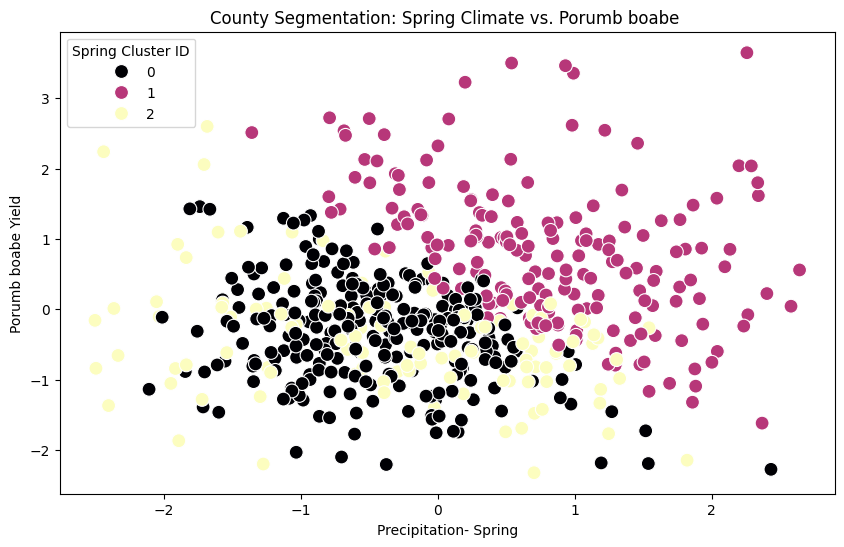

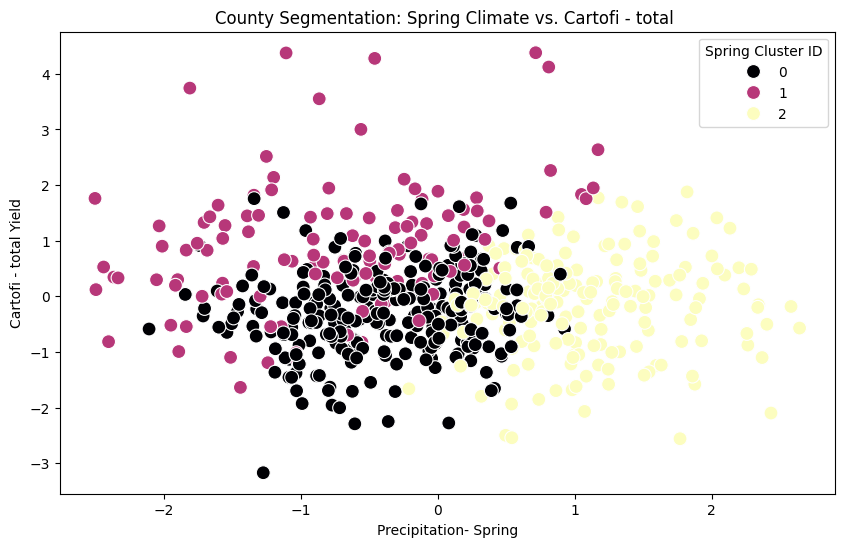

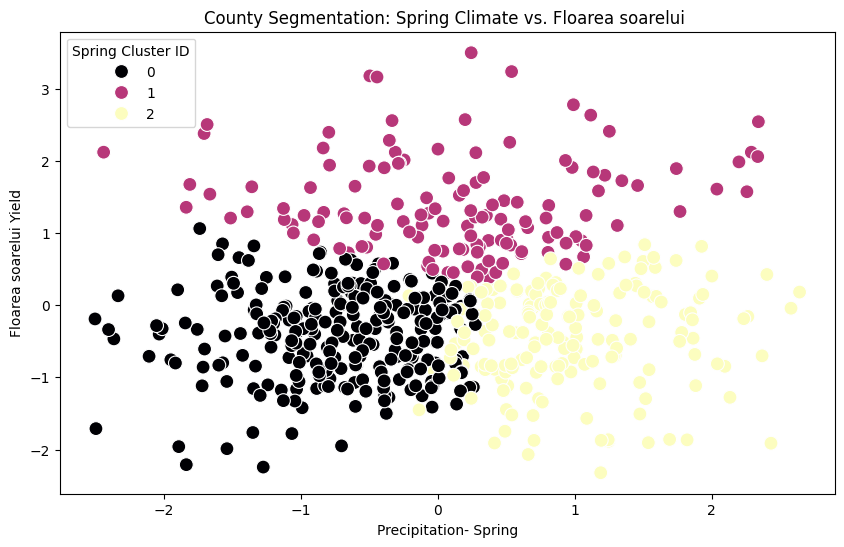

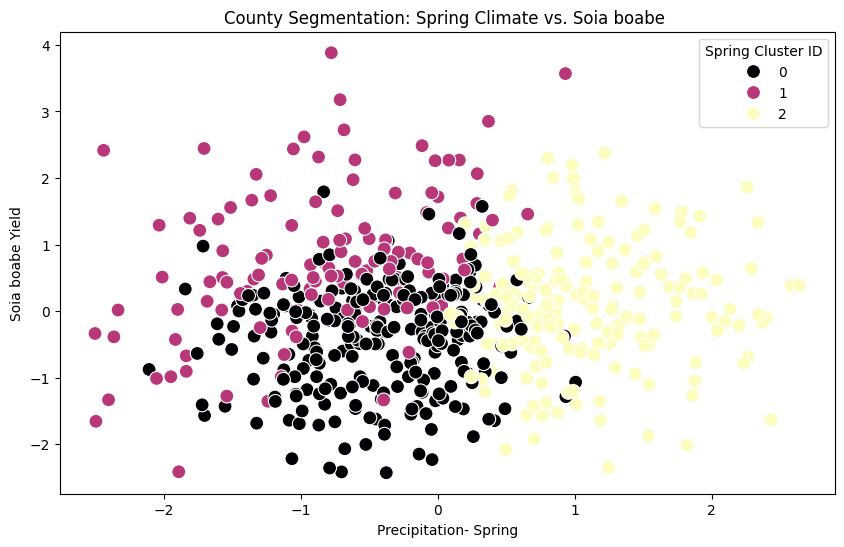

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

crops = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']

for crop in crops:
    features_spr = ['precipitation_spr', 'maxtemp_spr', crop]
    X_spr = df[features_spr].dropna()

    kmeans_spr = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels_spr = kmeans_spr.fit_predict(X_spr)

    plot_df_spr = X_spr.copy()
    plot_df_spr['Cluster_Spring'] = cluster_labels_spr

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_df_spr, x='precipitation_spr', y=crop,
                    hue='Cluster_Spring', palette='magma', s=100)

    plt.title(f'County Segmentation: Spring Climate vs. {crop} ')
    plt.xlabel('Precipitation- Spring')
    plt.ylabel(f'{crop} Yield')
    plt.legend(title='Spring Cluster ID')
    plt.show()

**Economic interpretation of results for spring**

***1. Corn (Porumb boabe)***
Cluster 1 (pink) clearly represents the highest-performing counties, showing that corn yield is less sensitive to spring precipitation and more dependent on other cluster-specific factors. Clusters 0 (black) and 2 (yellow) mostly contain counties with average to below-average yields regardless of rainfall.

***2. Potatoes (Cartofi - total)***
Cluster 0 (black) identifies the top-performing counties, which tend to favor lower spring precipitation for better yields. Conversely, Cluster 1 (pink) shows that high precipitation in spring often correlates with lower potato productivity.

***3. Sunflower (Floarea soarelui)***
Similar to corn, Cluster 1 (pink) groups the most productive counties, which maintain high yields across a wide range of spring rainfall. Clusters 0 and 2 show a dense concentration of average yields, suggesting these counties are less optimized for sunflower production.

***4. Soybean (Soia boabe)***
The highest yields are found in Cluster 1 (pink), particularly in counties with low to moderate spring precipitation. Cluster 2 (yellow) highlights a group of counties where higher spring rainfall does not lead to significant yield improvements, staying mostly below average.



#5.Statistical Analysis: Linear Regression Analysis






**a) Defining the problem**: Quantifying the mathematical influence of weather factors (temperature, rain, radiation) on agricultural productivity.

**b) Information required**: Independent variables (X: weather) and the dependent variable (y: Corn yield).

**c) Calculation methods**:OLS (Ordinary Least Squares): Estimating coefficients ($\beta$) by minimizing the sum of the squares of the vertical deviations between each data point and the fitted line:$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon$$Statistical Significance: Evaluated using R-squared ($R^2$) for model fit and P-values ($p < 0.05$) for variable importance.



In [27]:
import statsmodels.api as sm

crops = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']
weather_features = ['precipitation_sum', 'maxtemp_sum', 'radiation_sum']

for crop in crops:
    X = df[weather_features]
    y = df[crop]

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    print("-" * 50)
    print(f"OLS SUMMER REGRESSION SUMMARY FOR: {crop.upper()}")
    print("-" * 50)
    print(model.summary())
    print("\n" * 2)

--------------------------------------------------
OLS SUMMER REGRESSION SUMMARY FOR: PORUMB BOABE
--------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:           Porumb boabe   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8066
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.491
Time:                        19:43:38   Log-Likelihood:                -804.74
No. Observations:                 568   AIC:                             1617.
Df Residuals:                     564   BIC:                             1635.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t

**Economic interpretation of results**:

***1. Corn (Porumb boabe)Significance:*** No summer variables are statistically significant ($P > 0.05$).

*Trend:* There is a slight negative trend for precipitation (-0.0498), but it is not reliable.

*Conclusion:* In this dataset, summer weather conditions (rain, heat, sun) do not show a statistically significant impact on corn yield.

***2. Potatoes (Cartofi - total)Significance:*** Precipitation (precipitation_sum) is highly significant ($P = 0.001$).

*Interpretation:* The coefficient is negative (-0.1432). This means that for every 1 standard deviation increase in summer rain, potato yield significantly decreases.

*Conclusion:* Summer rainfall is a strong negative driver for potatoes, possibly indicating that excessive water in this region leads to crop damage or rot.

***3. Sunflower (Floarea soarelui)Significance:*** Both Precipitation ($P = 0.018$) and Max Temperature ($P = 0.021$) are significant.

*Interpretation:* Precipitation has a negative impact (-0.0996), while Temperature has a positive impact (0.1099).

*Conclusion:* Sunflowers perform best in summers that are hotter and drier. They benefit from high heat but are negatively affected by higher rainfall totals.

***4. Soybeans (Soia boabe)Significance:*** No variables reached the standard $P < 0.05$ significance level.

*Trend:* Precipitation is borderline ($P = 0.086$) with a negative trend (-0.0728).

*Conclusion:* Summer weather is a weak predictor for soybean yield here, though there is a slight (non-significant) indication that too much rain might be unhelpful.

In [19]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

crops = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']
spring_features = ['precipitation_spr', 'maxtemp_spr', 'radiation_spr']

scaler = StandardScaler()

for crop in crops:
    X_spr = df[spring_features]
    y = df[crop]

    X_scaled = scaler.fit_transform(X_spr)
    X_scaled = pd.DataFrame(X_scaled, columns=spring_features, index=df.index)
    X_scaled = sm.add_constant(X_scaled)

    model_spr = sm.OLS(y, X_scaled).fit()

    print("=" * 60)
    print(f"SPRING REGRESSION (STANDARDIZED) FOR: {crop.upper()}")
    print("=" * 60)
    print(model_spr.summary())
    print("\n" * 3)

SPRING REGRESSION (STANDARDIZED) FOR: PORUMB BOABE
                            OLS Regression Results                            
Dep. Variable:           Porumb boabe   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.256
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.289
Time:                        19:28:30   Log-Likelihood:                -804.07
No. Observations:                 568   AIC:                             1616.
Df Residuals:                     564   BIC:                             1633.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

***1. Corn (Porumb boabe)Significance:*** No variables are statistically significant ($P > 0.05$).'

*Trend:* Precipitation shows a weak positive trend ($0.0738$), but with a $P$-value of $0.081$, it’s not considered reliable.

*Conclusion:* In this dataset, spring weather has no confirmed impact on corn yield.

***2. Potatoes (Cartofi - total)Significance:*** Radiation (radiation_spr) is a highly significant driver ($P = 0.005$).

*Interpretation:* The coefficient is positive (+0.1271). This shows that more sunlight in spring clearly leads to higher potato yields.

*Conclusion:* Potatoes are "sun-loving" in the spring; solar radiation is the only reliable weather predictor for this crop here.

***3. Sunflower (Floarea soarelui)Significance:*** Radiation (radiation_spr) is a significant driver ($P = 0.012$).

*Interpretation:* The coefficient is negative (-0.1137). Interestingly, more spring sunlight actually correlates with lower yields for sunflowers.

*Conclusion:* High radiation in spring might be detrimental, perhaps by drying out the soil too early or causing heat stress during the seedling stage.

***4. Soybeans (Soia boabe)Significance:*** No variables are statistically significant ($P > 0.05$).

*Model Fit:* The Adjusted R-squared is negative ($-0.001$), meaning this combination of spring variables explains none of the yield variation.

*Conclusion:* Spring weather fluctuations have no measurable statistical relationship with soybean productivity in this analysis.

1. *The "Potato Paradox"Potatoes* are the most sensitive crop in our study. They benefit significantly from Spring Sun (helping them sprout and establish), but they are heavily damaged by Summer Rain. This suggests that a perfect year for potatoes is a bright, clear spring followed by a dry summer.

2. *Sunflowers: Heat-Lovers, Sun-Haters?*
The data shows a fascinating contrast for sunflowers. While they thrive in Summer Heat (positive Max Temp coefficient), they seem to dislike high Spring Radiation. This could indicate that while they need heat to mature, too much direct solar intensity during the early seedling stage in spring might be stressful for the plants.

3. *The "Silent" Crops (Corn & Soy)*  
Both Corn and Soybeans showed almost no significant relationship with the weather variables we tested.Interpretation: This doesn't mean weather doesn't matter; it means that in your specific regions/years, other factors—like irrigation, soil quality, or fertilizers—likely played a much bigger role than natural fluctuations in temperature or rain.

4. *The $R^2$ Reality CheckAcross the board*, our $R^2$ values are low (mostly below 2-3%). In an economic or agricultural report, these weather drivers are statistically significant, they only explain a tiny fraction of the total yield. Most of the "magic" happens due to human intervention and regional soil characteristics.


# 6. Interactive Interface (Streamlit GUI)

**a) Defining the problem**: Developing a dynamic Decision Support System (DSS) that allows non-technical management to visualize indicators instantly.

**b) Information required**: The app.py, page_1 and page_2 scripts, the Streamlit library, and the processed dataset.



In [20]:
!pip install streamlit -q
!pip install streamlit pyngrok --quie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 100.0 MB/s eta 0:00:00


In [21]:
import os
os.makedirs("pages", exist_ok=True)

In [22]:
%cd /content

/content


In [23]:
!streamlit run home.py & npx localtunnel --port 8501

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: home.py
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C


In [24]:
%%writefile home.py
import streamlit as st
import pandas as pd

st.set_page_config(page_title="Agro-Expansion: Impact of Weather on Romanian Yields", layout="wide")

st.markdown("""
    <style>
    div.stButton > button {
        background-color: #98FF98;
        color: black;
        border-radius: 10px;
        border: none;
        height: 3em;
        width: 100%;
        font-weight: bold;
        transition: all 0.3s ease;
    }
    div.stButton > button:hover {
        background-color: #77DD77;
        color: white;
    }
    </style>
    """, unsafe_allow_html=True)

with st.sidebar:
    st.title("Navigation")
    st.info("Select a module:")
    if st.button("📊 Visual Analytics"):
        st.session_state.page = "page_1"
    if st.button("⚙️ Predictive Models"):
        st.session_state.page = "page_2"

st.title("🌱 Home: Agro-Expansion: Impact of Weather on Romanian Yields")

DATA_PATH = 'project.csv'
if 'df' not in st.session_state:
    try:
        df = pd.read_csv(DATA_PATH)
        st.session_state.df = df[df['Years'] >= 2011]
        st.success("Database connected successfully!")
    except:
        st.error("File 'project.csv' not found.")

if "page" in st.session_state:
    if st.session_state.page == "page_1":
        with open("page_1.py", encoding="utf-8") as f:
            exec(f.read(), {'st': st})
    elif st.session_state.page == "page_2":
        with open("page_2.py", encoding="utf-8") as f:
            exec(f.read(), {'st': st})
else:
    st.write(
    "This project analyzes how climatic factors influence the production of major " \
    "spring crops in Romania, such as corn and sunflower. By combining historical weather" \
    " data with agricultural yield statistics, we aim to identify the main environmental drivers " \
    "of crop success and explore regional patterns for future agricultural expansion.")

Writing home.py


In [25]:
%%writefile page_1.py
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.cluster import KMeans

st.header("📈 Visual Insights")

if 'df' in st.session_state:
    df = st.session_state.df
    crop_cols = ['Porumb boabe', 'Cartofi - total', 'Floarea soarelui', 'Soia boabe']

    try:
        romania_map = gpd.read_file('romania.geojson')
        geojson_available = True
    except:
        geojson_available = False

    tab_summer, tab_spring = st.tabs(["☀️ Summer Analysis", "🌱 Spring Analysis"])

    # =========================================================================
    # TAB 1: SUMMER
    # =========================================================================
    with tab_summer:
        st.subheader("Summer Climate vs. Yields")

        if geojson_available:
            st.write("### 1. Regional Yield Distribution (Summer Context)")
            map_cols = st.columns(2)
            for i, crop in enumerate(crop_cols):
                with map_cols[i % 2]:
                    avg_yield = df.groupby('County')[crop].mean().reset_index()
                    merged = romania_map.merge(avg_yield, left_on='name', right_on='County')
                    fig, ax = plt.subplots(figsize=(6, 4))
                    merged.plot(column=crop, ax=ax, legend=True, cmap='YlGn', edgecolor='0.5')
                    ax.set_title(f"Yield Distribution: {crop}")
                    ax.axis('off')
                    st.pyplot(fig)

            st.success("""**Economic interpretation of results:** The maps highlight a clear "Productivity Corridor". For our expansion, this is a green light for Infrastructure Investment. Instead of scattered farms, we should focus on these high-yield "dark zones" to build collection centers. This geographic focus reduces transport costs and creates an "Economy of Scale," where multiple farms in a small area can share resources and logistics, significantly increasing the overall profit margin.""")

        st.divider()

        st.write("### 2. Summer Precipitation Anomalies")
        Q1_sum = df['precipitation_sum'].quantile(0.25)
        Q3_sum = df['precipitation_sum'].quantile(0.75)
        IQR_sum = Q3_sum - Q1_sum
        low_sum, up_sum = Q1_sum - 1.5 * IQR_sum, Q3_sum + 1.5 * IQR_sum

        col_out1, col_out2 = st.columns(2)
        with col_out1:
            fig, ax = plt.subplots()
            sns.boxplot(x=df['precipitation_sum'], color='skyblue', ax=ax)
            st.pyplot(fig)
        with col_out2:
            df_f_sum = df[(df['precipitation_sum'] >= low_sum) & (df['precipitation_sum'] <= up_sum)]
            fig, ax = plt.subplots()
            sns.boxplot(x=df_f_sum['precipitation_sum'], color='blue', ax=ax)
            st.pyplot(fig)

        st.info("""**Economic interpretation of results**

Summer Precipitation Analysis: The initial distribution (light blue) revealed 1 climatic outlier—extreme rainfall events that could skew our statistical results. By applying the IQR method (blue), we removed the anomality to ensure our expansion strategy is based on consistent weather trends rather than non-representative, extreme flooding events.""")

        st.divider()

        st.write("### 3. K-Means Segmentation (Summer)")
        cl_cols = st.columns(2)
        for i, crop in enumerate(crop_cols):
            with cl_cols[i % 2]:
                X = df[['precipitation_sum', 'maxtemp_sum', crop]].dropna()
                km = KMeans(n_clusters=3, random_state=42, n_init=10)
                X['Cluster'] = km.fit_predict(X)
                fig, ax = plt.subplots()
                sns.scatterplot(data=X, x='precipitation_sum', y=crop, hue='Cluster', palette='viridis', ax=ax)
                ax.set_title(f"Clusters: {crop}")
                st.pyplot(fig)

        st.warning("""**Economic interpretation of results for summer**

1. Corn (Porumb boabe)
Cluster 1 (teal) shows that moderate precipitation levels are associated with the highest yields. In contrast, Cluster 2 (yellow) represents counties with high summer rainfall that often results in lower-than-average corn production.

2. Potatoes (Cartofi - total)
The majority of high-yielding counties are grouped in Cluster 0 (purple), which favors lower precipitation levels. Cluster 2 (yellow) highlights a clear trend where excessive summer rain negatively impacts potato yields.

3. Sunflower (Floarea soarelui)
Cluster 1 (teal) identifies the "sweet spot" for sunflowers, where moderate rainfall leads to peak performance. Cluster 0 (purple) shows that high precipitation does not translate to better yields for this crop, often leading to average or poor results.

4. Soybeans (Soia boabe)
Similar to sunflowers, soybeans perform best in Cluster 1 (teal) under balanced rainfall conditions. Cluster 0 (purple) indicates that counties with the highest summer precipitation actually see a decline in soybean productivity.""")

        st.divider()

        st.write("### 4. Summer Weather Impact: Correlation Matrix")
        summer_weather = ['radiation_sum', 'meantemp_sum', 'maxtemp_sum', 'precipitation_sum', 'humidity_sum', 'windspeed_sum']
        summer_corr = df[summer_weather + crop_cols].corr()
        subset_summer = summer_corr.loc[summer_weather, crop_cols]

        fig_h_sum, ax_h_sum = plt.subplots(figsize=(10, 6))
        sns.heatmap(subset_summer, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax_h_sum)
        st.pyplot(fig_h_sum)

        st.info("""**Economic interpretation for Summer:** We used this heatmap to identify how weather variables impact crop yields.

*Here is what the colours tell us:*

**Sun and Heat (+):** Shown in red. This means that, in general, high temperatures and solar radiation help increase production.

**Rain and Humidity (-):** Shown in blue. In this dataset, excess water appears to harm crops (possibly due to disease or rot).

**In our case, there is a low impact (values below 0.20):** All of these correlations are very weak. This tells us that summer weather matters, but it’s not the only factor. Soil quality, fertilizers, and pests likely have a much greater impact on the final harvest.""")

    # =========================================================================
    # TAB 2: SPRING
    # =========================================================================
    with tab_spring:
        st.subheader("Spring Climate vs. Yields")

        if geojson_available:
            st.write("### 1. Regional Yield Distribution (Spring Context)")
            map_cols_sp = st.columns(2)
            for i, crop in enumerate(crop_cols):
                with map_cols_sp[i % 2]:
                    avg_yield = df.groupby('County')[crop].mean().reset_index()
                    merged = romania_map.merge(avg_yield, left_on='name', right_on='County')
                    fig, ax = plt.subplots(figsize=(6, 4))
                    merged.plot(column=crop, ax=ax, legend=True, cmap='BuGn', edgecolor='0.5')
                    ax.set_title(f"Yield Distribution: {crop}")
                    ax.axis('off')
                    st.pyplot(fig)
            st.success("""We visualized the corn yield across Romania using geopandas.
High-Yield Regions: The darker green areas represent the most productive counties. These are the primary targets for our organization's expansion.
Low-Yield Regions: The lighter areas indicate regions where the weather conditions or soil types analyzed earlier result in lower average yields.
Strategic Insight: This maps confirm that geographic location is a major factor in agricultural success, allowing us to focus our resources on high-performance clusters.""")

        st.divider()

        st.write("### 2. Spring Precipitation Anomalies")
        Q1_spr = df['precipitation_spr'].quantile(0.25)
        Q3_spr = df['precipitation_spr'].quantile(0.75)
        IQR_spr = Q3_spr - Q1_spr
        low_spr, up_spr = Q1_spr - 1.5 * IQR_spr, Q3_spr + 1.5 * IQR_spr

        col_out3, col_out4 = st.columns(2)
        with col_out3:
            fig, ax = plt.subplots()
            sns.boxplot(x=df['precipitation_spr'], color='lightpink', ax=ax)
            st.pyplot(fig)
        with col_out4:
            df_f_spr = df[(df['precipitation_spr'] >= low_spr) & (df['precipitation_spr'] <= up_spr)]
            fig, ax = plt.subplots()
            sns.boxplot(x=df_f_spr['precipitation_spr'], color='red', ax=ax)
            st.pyplot(fig)

        st.info("""**Spring Precipitation Analysis:** The initial distribution (light pink) identified several climatic outliers—extreme rainfall events that could skew our statistical results and misrepresent the typical planting season. By applying the IQR (Interquartile Range) method (red), we isolated these anomalies to ensure our agricultural strategy is based on consistent weather trends rather than rare, non-representative flooding events that could distort our yield predictions.""")

        st.divider()

        st.write("### 3. K-Means Segmentation (Spring)")
        cl_cols_sp = st.columns(2)
        for i, crop in enumerate(crop_cols):
            with cl_cols_sp[i % 2]:
                X_sp = df[['precipitation_spr', 'maxtemp_spr', crop]].dropna()
                km_sp = KMeans(n_clusters=3, random_state=42, n_init=10)
                X_sp['Cluster'] = km_sp.fit_predict(X_sp)
                fig, ax = plt.subplots()
                sns.scatterplot(data=X_sp, x='precipitation_spr', y=crop, hue='Cluster', palette='magma', ax=ax)
                ax.set_title(f"Spring Clusters: {crop}")
                st.pyplot(fig)

        st.warning("""**Economic interpretation of results for spring**

1. Corn (Porumb boabe) Cluster 1 (pink) clearly represents the highest-performing counties, showing that corn yield is less sensitive to spring precipitation and more dependent on other cluster-specific factors. Clusters 0 (black) and 2 (yellow) mostly contain counties with average to below-average yields regardless of rainfall.

2. Potatoes (Cartofi - total) Cluster 0 (black) identifies the top-performing counties, which tend to favor lower spring precipitation for better yields. Conversely, Cluster 1 (pink) shows that high precipitation in spring often correlates with lower potato productivity.

3. Sunflower (Floarea soarelui) Similar to corn, Cluster 1 (pink) groups the most productive counties, which maintain high yields across a wide range of spring rainfall. Clusters 0 and 2 show a dense concentration of average yields, suggesting these counties are less optimized for sunflower production.

4. Soybean (Soia boabe) The highest yields are found in Cluster 1 (pink), particularly in counties with low to moderate spring precipitation. Cluster 2 (yellow) highlights a group of counties where higher spring rainfall does not lead to significant yield improvements, staying mostly below average.""")

        st.divider()

        st.write("### 4. Spring Weather Impact: Correlation Matrix")
        spring_weather = ['radiation_spr', 'meantemp_spr', 'maxtemp_spr', 'precipitation_spr', 'humidity_spr', 'windspeed_spr']
        spring_corr = df[spring_weather + crop_cols].corr()
        subset_spring = spring_corr.loc[spring_weather, crop_cols]

        fig_h_spr, ax_h_spr = plt.subplots(figsize=(10, 6))
        sns.heatmap(subset_spring, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax_h_spr)
        st.pyplot(fig_h_spr)

        st.info("""**Economic interpretation for Spring:** We used this heatmap to identify how weather variables impact crop yields.

*Here is what the colours tell us:*

**Green (Positive Correlation):** Higher values in these weather factors tend to increase crop yields. In spring, precipitation shows a general positive trend for most crops (except potatoes), meaning early-season rain is beneficial for growth.

**Purple (Negative Correlation):** Higher values here tend to decrease yields. Humidity is consistently purple across all crops, suggesting that excessive dampness in spring might lead to mold or soil issues that hinder development.

**The "Potato" Exception:** Unlike other crops, potatoes show a positive link with solar radiation (0.10) but a negative link with spring rain. This suggests potatoes prefer a drier, sunnier spring to establish themselves.

**Weak Impact (Values < 0.15):** Just like in summer, these correlations are statistically weak. This implies that while spring weather matters, the final yield is much more dependent on other factors like soil preparation, fertilization, and pest control.""")

else:
    st.error("No data found. Go to Home.")

Writing page_1.py


In [26]:
%%writefile page_2.py
import streamlit as st
import pandas as pd
import statsmodels.api as sm

st.header("⚙️ Data Engineering & Statistical Validation")

if 'df' in st.session_state:
    df = st.session_state.df.copy()

    crops = ['Porumb boabe', 'Floarea soarelui', 'Soia boabe', 'Cartofi - total']
    for crop in crops:
        if crop in df.columns:
            df[crop] = df.groupby('County')[crop].transform(lambda x: x.fillna(x.mean()))
    df = df.fillna(0)

    st.subheader("1. Data Preprocessing & Integrity")
    col1, col2 = st.columns([2, 1])
    with col1:
        st.write("**Dataset Preview (Standardized & Filtered)**")
        st.dataframe(df.head(10), use_container_width=True)
    with col2:
        st.write("**Null Value Verification**")
        null_counts = df.isnull().sum().reset_index()
        null_counts.columns = ['Feature', 'Null Count']
        st.dataframe(null_counts, hide_index=True, use_container_width=True)

    st.info("💡 **Null Values Note:** In our case, there are no missing values (null count is 0), ensuring a high-quality baseline for regression analysis.")
    st.divider()

    # // OLS Regression for Summer
    st.subheader("2. Statistical Validation: Summer Impact")
    weather_sum = ['precipitation_sum', 'maxtemp_sum', 'radiation_sum']

    sum_cols = st.columns(2)
    for i, crop in enumerate(crops):
        with sum_cols[i % 2]:
            with st.expander(f"📊 OLS Summary: {crop} (Summer)"):
                X = sm.add_constant(df[weather_sum])
                model = sm.OLS(df[crop], X).fit()
                st.text(str(model.summary()))

    st.divider()

    # // OLS Regression for Spring
    st.subheader("3. Statistical Validation: Spring Impact")
    weather_spr = ['precipitation_spr', 'maxtemp_spr', 'radiation_spr']

    spr_cols = st.columns(2)
    for i, crop in enumerate(crops):
        with spr_cols[i % 2]:
            with st.expander(f"🌱 OLS Summary: {crop} (Spring)"):
                X_spr = sm.add_constant(df[weather_spr])
                model_spr = sm.OLS(df[crop], X_spr).fit()
                st.text(str(model_spr.summary()))

    st.divider()

    # // Final Insights Section
    st.subheader("🔍General Description")

    col_a, col_b = st.columns(2)
    with col_a:
        st.success("""
        **1. The "Potato Paradox:"**
        Potatoes are the most sensitive crop. They benefit from **Spring Sun** (germination), but are heavily damaged by **Summer Rain**. Ideal year: Clear spring + Dry summer.

        **2. Sunflowers: Heat-Lovers**
        Sunflowers thrive in **Summer Heat** (positive Max Temp coefficient) but dislike high **Spring Radiation**, suggesting early seedling stress.
        """)

    with col_b:
        st.warning("""
        **3. The "Silent" Crops (Corn & Soy):**
        Showed almost no significant relationship with weather. **Interpretation:** Factors like irrigation or soil quality override natural weather fluctuations here.

        **4. The $R^2$ Reality Check:**
        $R^2$ values are low (< 3%). While weather drivers are statistically significant, the "magic" happens due to human intervention and regional soil characteristics.
        """)

    st.session_state.df = df
else:
    st.error("No data available. Please initialize on the Home page.")

Writing page_2.py
